# Classically Punk

The genres data can be found on Kaggle: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

In [16]:
import librosa 
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
import torch.nn as nn
import mlflow
import seaborn as sns

from torch.utils.data import Dataset, DataLoader, TensorDataset
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

%matplotlib inline

In [2]:
tracking_uri = "http://127.0.0.1:5000"
mlflow.set_tracking_uri(tracking_uri)
experiment = mlflow.set_experiment("classically_punk")
mlflow.pytorch.autolog()

Define functions:

In [2]:
def smooth_curve(values, smoothing_factor=0.9):
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * smoothing_factor + (1 - smoothing_factor) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return np.array(smoothed)


def plot_train_test_losses(train_losses, test_losses, title="Training vs Testing Loss",
                           smooth=True, smoothing_factor=0.9):
    train_losses = np.array(train_losses)
    test_losses = np.array(test_losses)

    if smooth:
        train_losses = smooth_curve(train_losses, smoothing_factor)
        test_losses = smooth_curve(test_losses, smoothing_factor)

    x_train = np.linspace(0, 1, len(train_losses))
    x_test = np.linspace(0, 1, len(test_losses))

    plt.figure(figsize=(10, 5))
    plt.plot(x_train, train_losses, label="Training Loss", alpha=0.8)
    plt.plot(x_test, test_losses, label="Testing Loss", alpha=0.8)
    plt.title(title, fontsize=14)
    plt.xlabel("Normalized Progress", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

def val_loop(dataloader, loss_fn):
    y_preds = []
    y_tests = []
    
    model.eval() 
    with torch.inference_mode():
        for test_batch in dataloader:
            x_t, y_t = test_batch
            
            test_pred = model(x_t)
    
            test_loss = loss_fn(test_pred, y_t)
            
            y_pr = torch.argmax(test_pred, dim=1)
            
            y_preds.append(y_pr)
            y_tests.append(y_t)

    y_preds = torch.concatenate(y_preds)
    y_tests = torch.concatenate(y_tests)

    return y_preds, y_tests

def plot_pred_test_comparison(y_preds, y_tests):
    num_pairs = min(len(y_preds), len(y_tests))
    fig, axes = plt.subplots(num_pairs, 1, figsize=(10, 2*num_pairs), sharex=True)
    
    if num_pairs == 1:
        axes = [axes]
    
    for i in range(num_pairs):
        x1 = y_preds[i].numpy()
        x2 = y_tests[i].numpy()
        axes[i].plot(x1, label=f"Prediction Values - Tensor {i}", marker="o")
        axes[i].plot(x2, label=f"True Values- Tensor {i}", marker="x")
        axes[i].legend()
        axes[i].set_title(f"Comparison of Tensor {i}")
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()
        

## Data Exploration

In [3]:
genres = ["rock", "blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae"]

I will explore how each genre looks like as a wave to familarize my self.

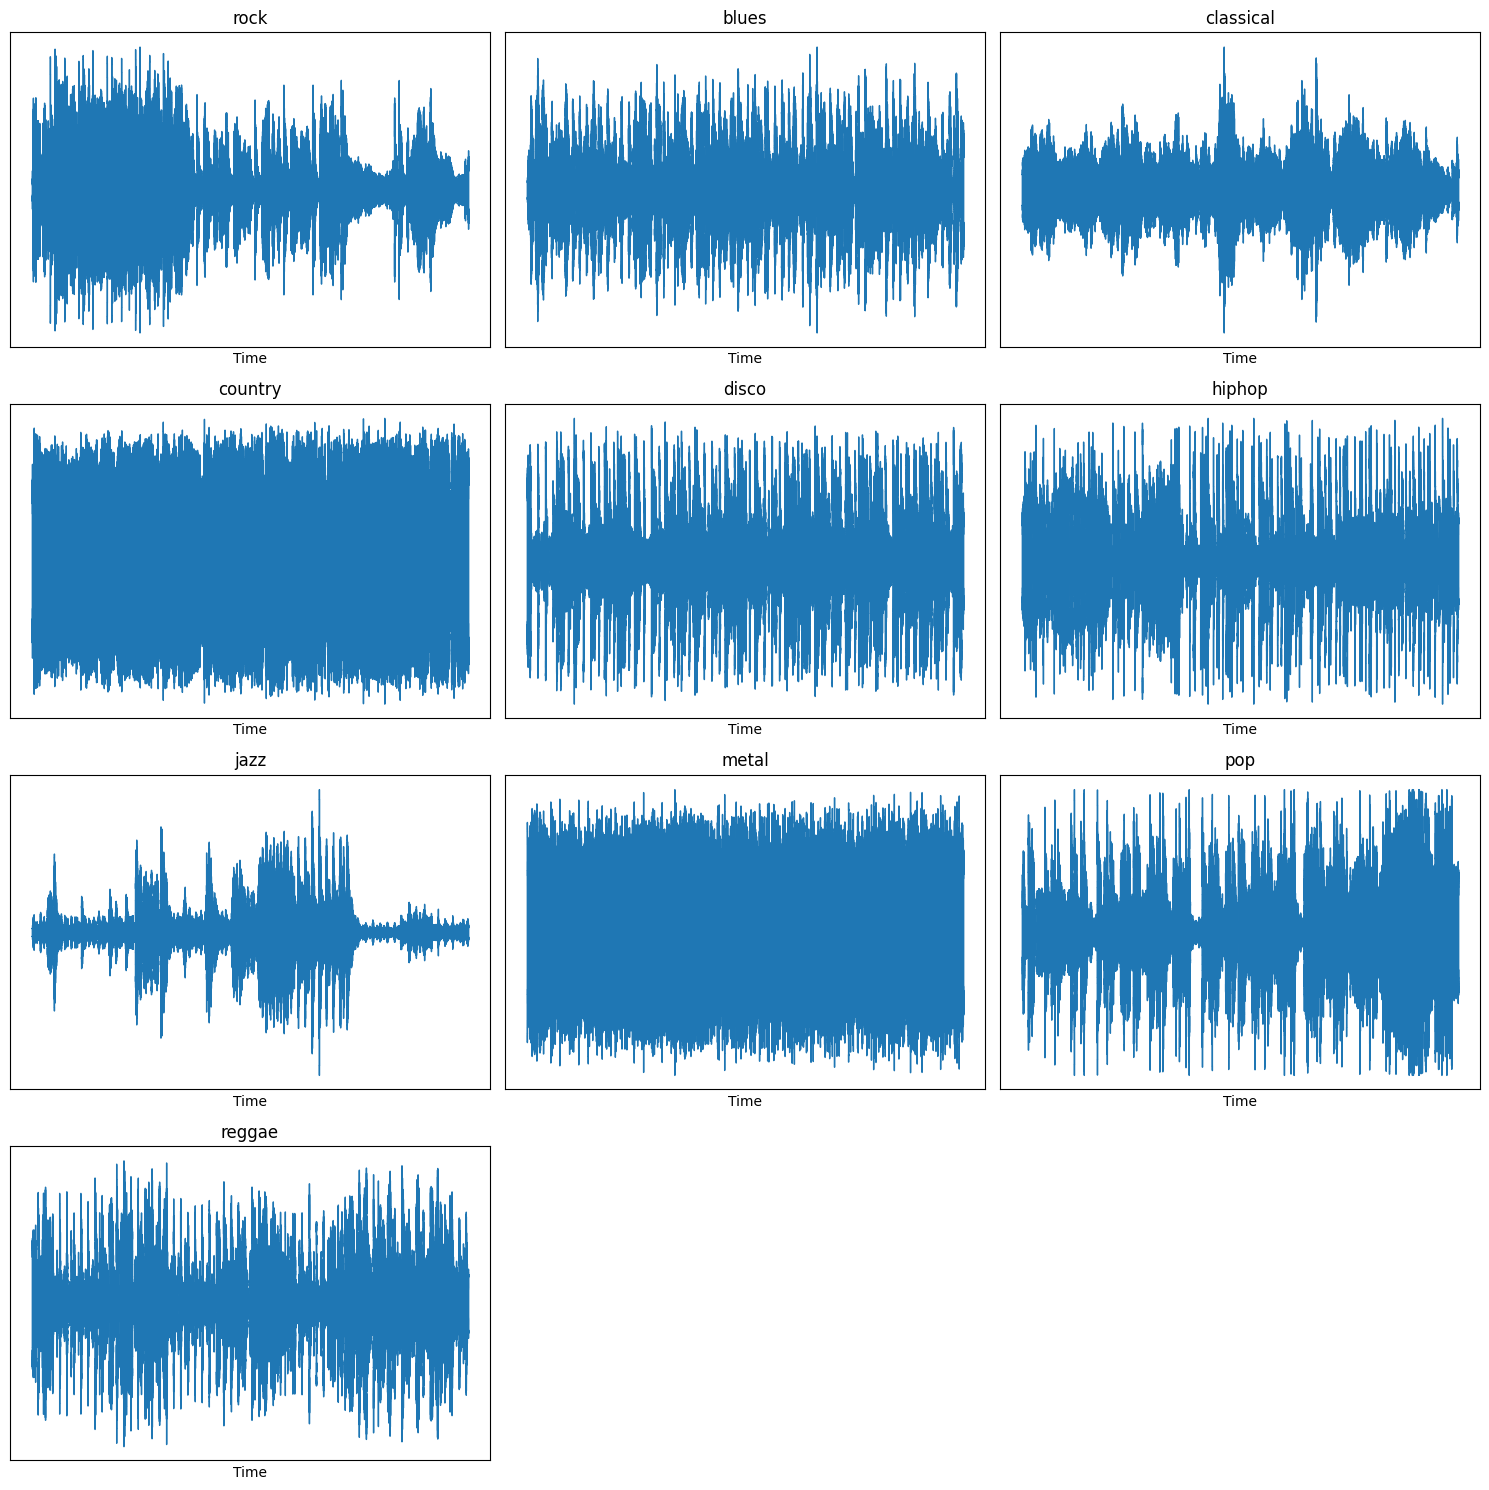

In [4]:
fig, axs = plt.subplots(4, 3, figsize=(15, 15))
axs = axs.flatten()

for idx, genre in enumerate(genres):
    audio_path = f'genres/{genre}/{genre}.00000.wav'
    x, sr = librosa.load(audio_path)
    librosa.display.waveshow(x, sr=sr, ax=axs[idx])
    axs[idx].set_title(genre)
    axs[idx].set_xticks([])
    axs[idx].set_yticks([])

for ax in axs[10:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Now, I will explore how each genre looks like as a spectrogram again to familarize my self.

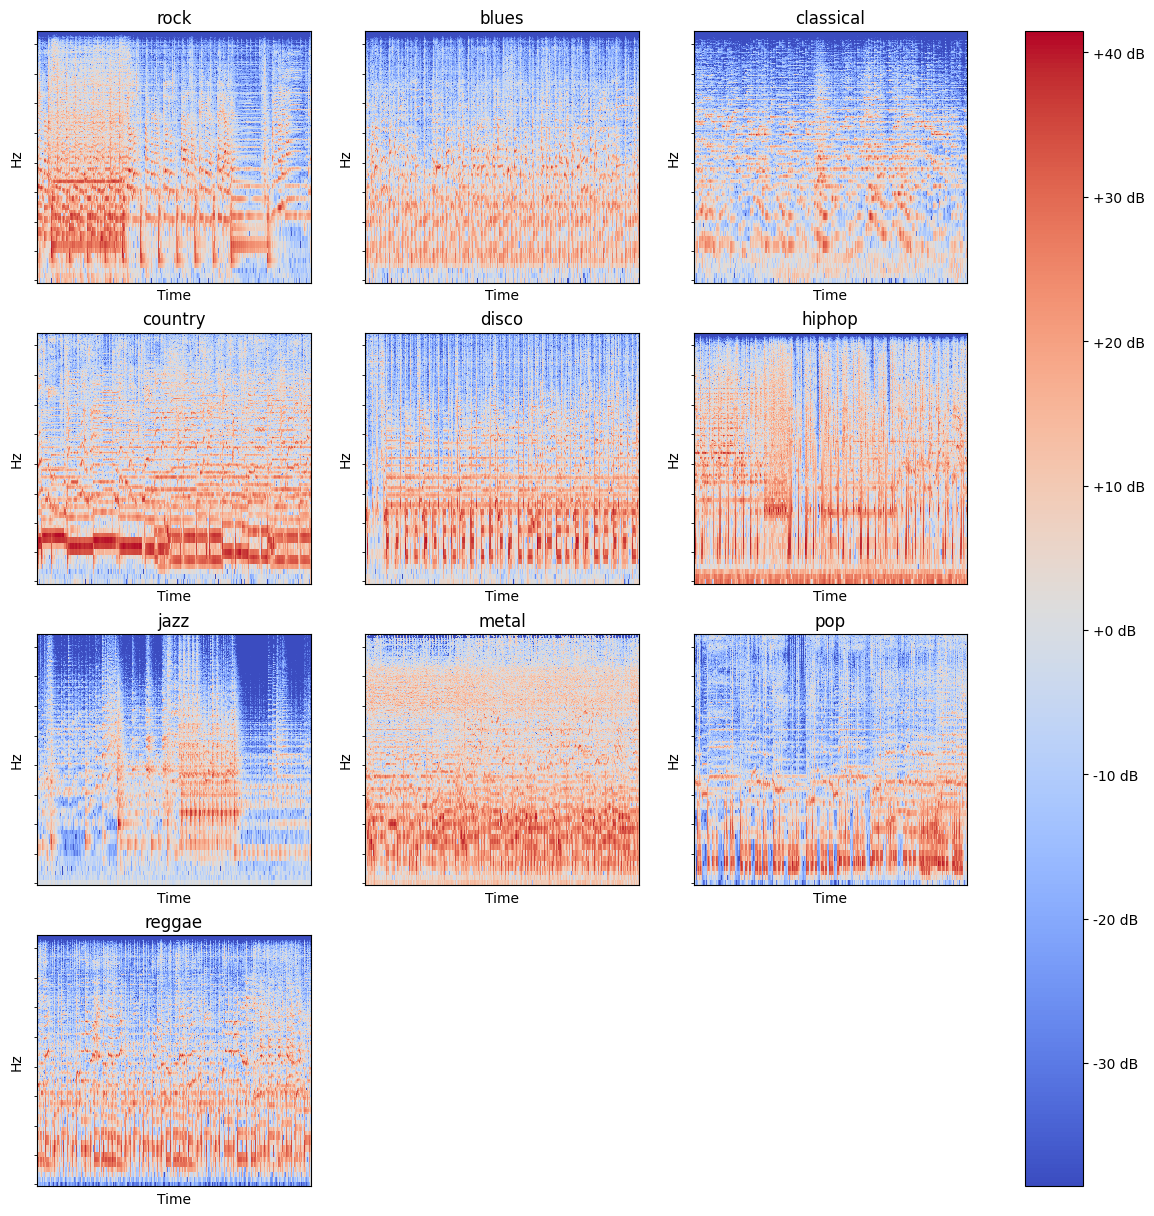

In [5]:
fig, axs = plt.subplots(4, 3, figsize=(15, 15))
axs = axs.flatten()

for idx, genre in enumerate(genres):
    audio_path = f'genres/{genre}/{genre}.00000.wav'
    x, sr = librosa.load(audio_path)
    X = librosa.stft(x)
    Xdb = librosa.amplitude_to_db(abs(X))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log', ax=axs[idx])
    axs[idx].set_title(genre)
    axs[idx].set_xticks([])
    axs[idx].set_yticks([])

for ax in axs[10:]:
    ax.axis("off")
    
fig.colorbar(img, ax=axs, format="%+2.f dB")

plt.show()

## Feature extraction

* Feature 1 - Zero Crossings - The zero-crossing rate is the rate of sign-changes along with a signal, i.e., the rate at which the signal changes from positive to negative or back.
* Feature 2 - Spectral Centroids - It indicates where the " center of mass" for a sound is located and is calculated as the weighted mean of the frequencies present in the sound.
* Feature 3 - Spectral Rolloff - It is a measure of the shape of the signal. It represents the frequency below which a specified percentage of the total spectral energy, e.g., 85%, lies.
* Feature 4 - MFCCs - The Mel frequency cepstral coefficients (MFCCs) of a signal are a small set of features (usually about 10–20) that concisely describe the overall shape of a spectral envelope.
* Feature 5 - Chroma Frequencies - Chroma features are an interesting and powerful representation for music audio in which the entire spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma) of the musical octave.


In [7]:
def feature_extract(x, sr):
    raw_features = {}
    raw_features["zero_crossings"] = librosa.zero_crossings(x, pad=False)
    raw_features["spectral_centroids"] = librosa.feature.spectral_centroid(y=x, sr=sr)[0]
    raw_features["spectral_rolloff"] = librosa.feature.spectral_rolloff(y=x+0.01, sr=sr)[0]
    raw_features["mfccs"] = librosa.feature.mfcc(y=x, sr=sr)
    hop_length = 512
    raw_features["chromagram"] = librosa.feature.chroma_stft(y=x, sr=sr, hop_length=hop_length)
    raw_features["duration"] = librosa.get_duration(y=x, sr=sr)
    return raw_features

In [8]:
def generate_df(raw_features):
    new_df = pd.DataFrame()
    new_df["duration"] = [raw_features["duration"]]
    new_df["zero_crossing_rate_mean"] = [np.mean(raw_features["zero_crossings"])]
    new_df["zero_crossing_rate_var"] = [np.var(raw_features["zero_crossings"])]
    new_df["chroma_stft_mean"] = [np.mean(raw_features["chromagram"])]
    new_df["chroma_stft_var"] = [np.var(raw_features["chromagram"])]
    new_df["spectral_centroid_mean"] = [np.mean(raw_features["spectral_centroids"])]
    new_df["spectral_centroid_var"] = [np.var(raw_features["spectral_centroids"])]
    new_df["spectral_rolloff_mean"] = [np.mean(raw_features["spectral_rolloff"])]
    new_df["spectral_rolloff_var"] = [np.var(raw_features["spectral_rolloff"])]

    mfccs = raw_features["mfccs"]
    mfccs_means = np.mean(mfccs, axis=1)   
    mfccs_vars = np.var(mfccs, axis=1)
    
    for i in range(len(mfccs_means)):
        new_df[f"mfcc{i+1}_mean"] = mfccs_means[i]
        new_df[f"mfcc{i+1}_var"] = mfccs_vars[i]
        
    return new_df

In [9]:
df = pd.DataFrame()

for genre in genres:
    pathlist = Path(f"genres/{genre}").glob('**/*.wav')
    for path in pathlist:
        audio_path = str(path)   
        x, sr = librosa.load(audio_path)
        raw_features = feature_extract(x, sr)
        new_df = generate_df(raw_features)
        new_df["audio_path"] = [audio_path]
        new_df["genre"] = [genre]
        df = pd.concat([df, new_df])


In [10]:
df.head(10)

,duration,zero_crossing_rate_mean,zero_crossing_rate_var,chroma_stft_mean,chroma_stft_var,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,mfcc1_mean,...,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,audio_path,genre
0,30.013333,0.054419,0.051457,0.343304,0.088840,1537.468449,491539.222968,3365.632987,2.399023e+06,-169.683121,...,-4.370689,71.076286,1.172074,96.772148,0.487476,79.974068,-5.829065,75.677567,genres/rock/rock.00011.wav,rock
0,30.013333,0.077137,0.071187,0.376758,0.081911,1542.109295,112771.940438,2856.346920,6.326828e+05,-62.364849,...,-2.277512,27.141008,-5.244769,41.878750,-5.225095,28.841183,-6.276886,33.442474,genres/rock/rock.00005.wav,rock
0,30.013333,0.122933,0.107820,0.442636,0.072727,2559.166385,237199.771519,5405.908146,1.833627e+06,-50.849358,...,-1.575925,17.213970,-3.856851,19.390163,-6.144731,18.558167,-5.379481,17.193031,genres/rock/rock.00039.wav,rock
0,29.995828,0.140760,0.120947,0.411478,0.084623,2794.963092,337551.767364,5848.522968,1.571478e+06,-15.928070,...,-1.577643,55.314949,1.581098,47.192097,0.412815,72.592552,2.938724,49.908951,genres/rock/rock.00038.wav,rock
0,30.013333,0.041146,0.039453,0.371823,0.088695,1345.841383,476337.645336,2909.497127,2.559444e+06,-127.970406,...,-5.323316,46.326420,-0.843005,43.065781,-4.661474,27.124546,-4.788684,27.636402,genres/rock/rock.00004.wav,rock
0,30.013333,0.071824,0.066666,0.398271,0.087783,1857.972599,379959.172087,4157.506956,1.664719e+06,-108.948036,...,-11.798590,45.530430,-6.499074,39.328686,-4.303898,48.186462,-2.736336,33.109138,genres/rock/rock.00010.wav,rock
0,30.013333,0.087446,0.079799,0.344484,0.088035,1676.146048,209843.569368,3235.825909,7.310830e+05,-98.386490,...,-8.629558,65.665977,-1.890370,52.954563,-2.185492,41.101078,-3.397589,44.949505,genres/rock/rock.00006.wav,rock
0,30.013333,0.068363,0.063689,0.338949,0.098358,1863.764472,812510.114355,3920.150438,2.787029e+06,-204.604706,...,-9.628987,57.548325,-7.385819,55.118099,-9.435307,38.829109,-3.133871,46.775032,genres/rock/rock.00012.wav,rock
0,30.013333,0.046173,0.044041,0.440252,0.092675,1597.518016,704726.779147,3765.779188,4.573432e+06,-211.216751,...,-6.636384,81.413345,-1.277511,97.177780,2.781899,106.339111,6.266782,77.187325,genres/rock/rock.00013.wav,rock
0,30.013333,0.047244,0.045012,0.359125,0.087730,1282.197334,299724.661206,2643.704457,1.624868e+06,-140.464172,...,-6.488681,53.077278,-4.709777,49.610229,-2.570159,34.243237,-1.791593,28.876339,genres/rock/rock.00007.wav,rock


In [11]:
df.shape

(1000, 51)

In [12]:
df.describe()

,duration,zero_crossing_rate_mean,zero_crossing_rate_var,chroma_stft_mean,chroma_stft_var,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,mfcc1_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,30.024075,0.103768,0.091248,0.378719,0.086345,2201.887215,4.695929e+05,4510.385149,1.839928e+06,-144.497314,...,1.148273,60.714851,-3.967269,62.614868,0.507468,63.695969,-2.329926,66.211205,-1.095509,70.110397
std,0.080910,0.041886,0.032323,0.081704,0.007739,715.916104,4.007595e+05,1611.363501,1.431312e+06,100.218719,...,4.579028,33.784050,4.549767,33.469387,3.869681,34.388195,3.755824,37.166142,3.837095,45.233253
min,29.931973,0.021727,0.021255,0.171897,0.044571,570.349904,7.996725e+03,647.286754,1.269754e+04,-552.158630,...,-15.693879,9.200758,-17.237364,13.870571,-11.981186,15.401894,-18.505384,13.417371,-19.928354,7.871336
25%,30.000181,0.070332,0.065385,0.319612,0.082358,1627.911508,1.845128e+05,3332.215304,7.628167e+05,-200.773685,...,-1.863282,40.335190,-7.205973,40.807056,-2.004486,41.860617,-4.666947,41.714985,-3.367671,42.308999
50%,30.013333,0.099613,0.089691,0.383192,0.086616,2209.334372,3.384935e+05,4611.777604,1.458371e+06,-120.327309,...,1.215503,52.256985,-4.070210,54.757240,0.670040,54.753153,-2.393430,57.425217,-1.164691,59.157099
75%,30.013333,0.132133,0.114674,0.435652,0.091259,2691.335270,6.121681e+05,5503.575711,2.543377e+06,-73.962498,...,4.365737,71.447191,-0.845321,75.036001,3.117758,75.401909,0.151603,78.552641,1.305560,85.292044
max,30.648889,0.274987,0.199369,0.663652,0.108057,4435.732059,3.033959e+06,8664.824377,8.723025e+06,42.091446,...,13.465460,393.005707,11.470961,405.928711,15.394898,332.782013,14.700517,393.373779,15.361670,506.306854


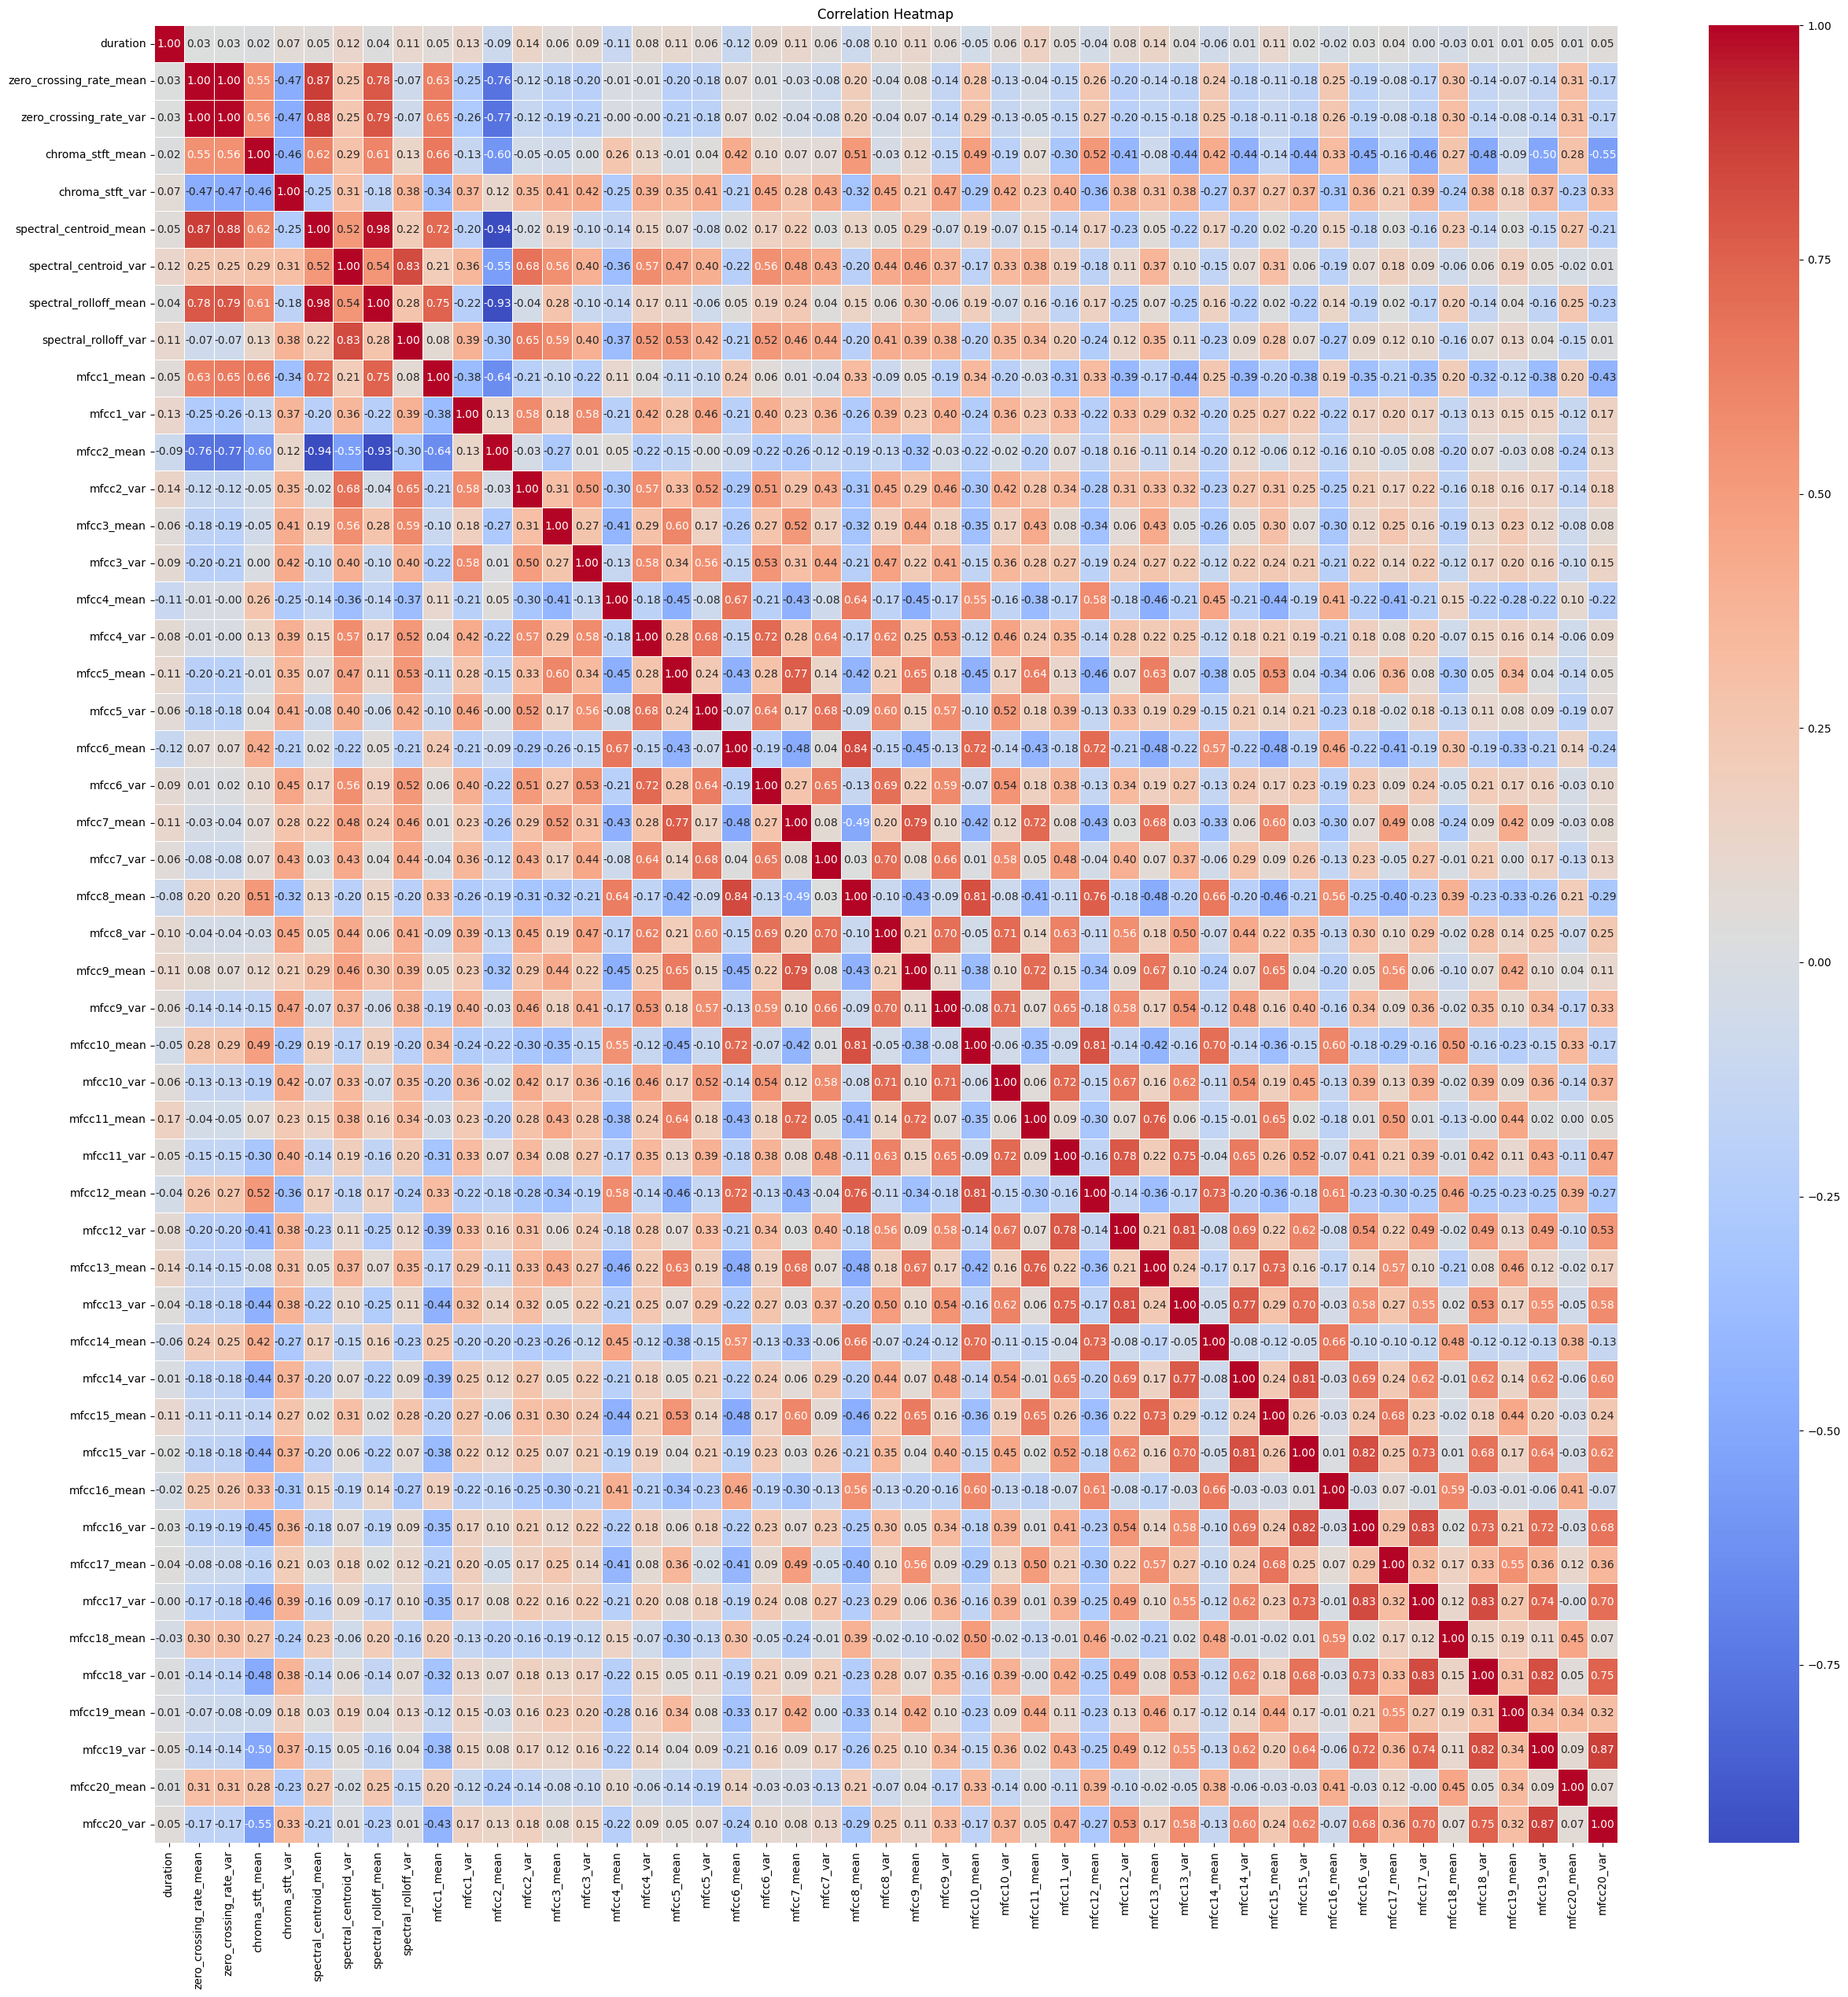

In [21]:
matrix = df.corr(numeric_only=True)

plt.figure(figsize=(30, 30))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [13]:
df.to_csv("audio_data.csv", index=False)

## Dataset preprocessing

In [22]:
df = pd.read_csv("audio_data.csv")

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   duration                 1000 non-null   float64
 1   zero_crossing_rate_mean  1000 non-null   float64
 2   zero_crossing_rate_var   1000 non-null   float64
 3   chroma_stft_mean         1000 non-null   float64
 4   chroma_stft_var          1000 non-null   float64
 5   spectral_centroid_mean   1000 non-null   float64
 6   spectral_centroid_var    1000 non-null   float64
 7   spectral_rolloff_mean    1000 non-null   float64
 8   spectral_rolloff_var     1000 non-null   float64
 9   mfcc1_mean               1000 non-null   float64
 10  mfcc1_var                1000 non-null   float64
 11  mfcc2_mean               1000 non-null   float64
 12  mfcc2_var                1000 non-null   float64
 13  mfcc3_mean               1000 non-null   float64
 14  mfcc3_var                

First of all, I need to encode the categorical target to be able to train a model.

In [24]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["genre"])
y

array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,

In [25]:
X = df.drop(columns=["genre", "audio_path"])

After, I have encoded the data, it is time for train/test split.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [27]:
X_train.shape, X_test.shape

((700, 49), (300, 49))

Next, I have to standardize the rest features. I will be utilizing the RobustScaler. I have tried StandardScaler and MinMaxScaler but they were much worse, StandardScaler was around 0.07 worse than RobustScaler and the MinMaxScaler was even worse with difference more than 20% compared to the RobustScaler.

In [28]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Building

In [29]:
# Baseline model for comparison
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.61      0.62        31
           1       1.00      0.96      0.98        26
           2       0.65      0.52      0.58        29
           3       0.53      0.59      0.56        32
           4       0.67      0.59      0.62        34
           5       0.86      0.80      0.83        30
           6       0.85      0.85      0.85        26
           7       0.83      0.94      0.88        31
           8       0.61      0.73      0.67        30
           9       0.52      0.52      0.52        31

    accuracy                           0.70       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.70      0.70       300



/Users/nikolaykirilov/Documents/University/qwasar/classically_punk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Baseline:**
* Precision: 0.71
* Recall: 0.71
* Accuracy: 0.70
* F1 Score: 0.70

Dataset setting:

In [30]:
class AudioFeaturesDataset(Dataset):
    def __init__(self, X, y, features):
        self.feature_columns = features
        self.X = X.astype("float32")
        self.y = y.astype("float32")

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


Model definition:

In [31]:
class AudioFCClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

Data loaders definition:

Train/Test loop with cross-validation:

In [32]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=1)

f1_scores = []
all_y_true = []
all_y_pred = []

features = df.drop(columns=["audio_path", "genre"]).columns

BATCH_SIZE = 16
EPOCHS = 401

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")

    # Split into raw train/val data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Scaling the data with RobustScaler. Firstly, tried with StandardScalar, but the Robust one performed about 20% better.
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # Fit on train only
    X_val_scaled = scaler.transform(X_val)           # Transform validation
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    
    # Create datasets
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    
    # Initialize model, loss, optimizer, scheduler
    num_features = len(features)
    num_classes = 10
    model = AudioFCClassifier(num_features, num_classes)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.005) # I have chosen this one because there is noise in the dataset. 
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.05, patience=20
    )

    # MLflow run for this fold
    with mlflow.start_run(run_name=f"fold_{fold+1}_audio_model"):
        mlflow.log_params({
            "fold": fold+1,
            "model_class": model.__class__.__name__,
            "optimizer": optimizer.__class__.__name__,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "loss_fn": loss_fn.__class__.__name__,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "scheduler_mode": scheduler.mode,
            "scheduler_factor": scheduler.factor,
            "scheduler_patience": scheduler.patience
        })
        
        loss_values = []
        test_loss_values = []
        
        for epoch in range(EPOCHS):
            # Training loop
            model.train()
            for x_tr, y_tr in train_dataloader:
                optimizer.zero_grad()
                y_pr = model(x_tr)
                loss = loss_fn(y_pr, y_tr)
                loss.backward()
                optimizer.step()
                loss_values.append(loss.detach().cpu())
            
            mean_train_loss = float(torch.mean(torch.stack(loss_values)))
            
            # Validation loop
            model.eval()
            test_loss_values = []
            with torch.inference_mode():
                for x_t, y_t in val_dataloader:
                    test_pred = model(x_t)
                    test_loss = loss_fn(test_pred, y_t)
                    test_loss_values.append(test_loss.detach().cpu())
                
                scheduler.step(torch.mean(torch.stack(test_loss_values)))
            
            mean_test_loss = float(torch.mean(torch.stack(test_loss_values)))
            
            # Logging metrics
            mlflow.log_metrics({
                "train_loss": loss,
                "mean_train_loss": mean_train_loss,
                "val_loss": test_loss,
                "mean_val_loss": mean_test_loss
            }, step=epoch)
        
        # Compute F1 on validation set
        y_preds, y_tests = val_loop(val_dataloader, loss_fn)
        all_y_true.append(y_tests.cpu().numpy())
        all_y_pred.append(y_preds.cpu().numpy())
        curr_f1_score = f1_score(y_tests.cpu().numpy(), y_preds.cpu().numpy(), average="weighted")
        print(f"Fold {fold+1} F1 score: {curr_f1_score:.4f}")
        mlflow.log_metric("f1_score", curr_f1_score)
        f1_scores.append(curr_f1_score)
    

mean_f1 = sum(f1_scores) / k
print(f"\nCross-validated F1 score: {mean_f1:.4f}")

# Log the overall CV F1 in MLflow
with mlflow.start_run(run_name="cross_validated_results", nested=True):
    mlflow.log_metric("cross_validated_mean_f1", mean_f1)
    for i, score in enumerate(f1_scores, 1):
        mlflow.log_metric(f"fold_{i}_f1", score)



--- Fold 1 ---
Fold 1 F1 score: 0.8099

--- Fold 2 ---
Fold 2 F1 score: 0.7783

--- Fold 3 ---
Fold 3 F1 score: 0.7901

--- Fold 4 ---
Fold 4 F1 score: 0.8188

--- Fold 5 ---
Fold 5 F1 score: 0.7926

Cross-validated F1 score: 0.7979


In [33]:
all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)

print(classification_report(all_y_true, all_y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7732    0.7500    0.7614       100
           1     0.9362    0.8800    0.9072       100
           2     0.7419    0.6900    0.7150       100
           3     0.7600    0.7600    0.7600       100
           4     0.8526    0.8100    0.8308       100
           5     0.8286    0.8700    0.8488       100
           6     0.8713    0.8800    0.8756       100
           7     0.8667    0.9100    0.8878       100
           8     0.7248    0.7900    0.7560       100
           9     0.6238    0.6300    0.6269       100

    accuracy                         0.7970      1000
   macro avg     0.7979    0.7970    0.7969      1000
weighted avg     0.7979    0.7970    0.7969      1000



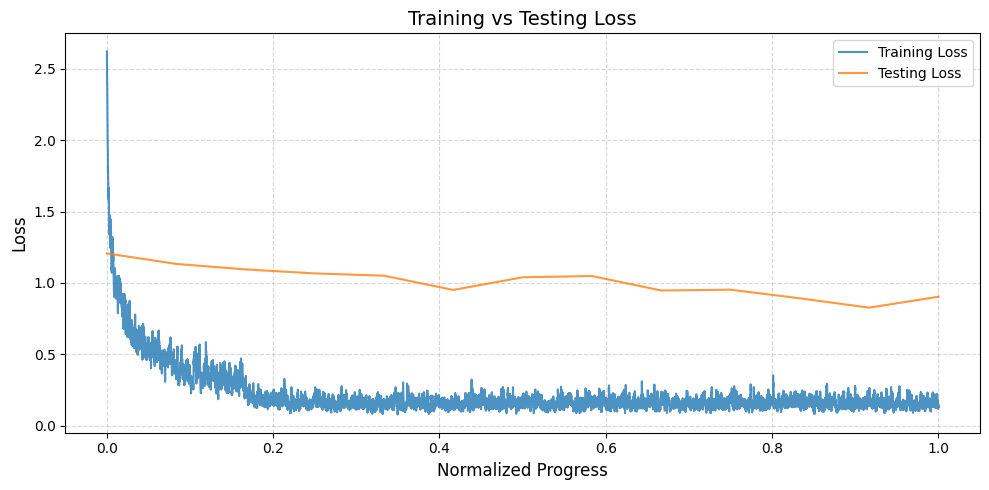

In [34]:
plot_train_test_losses(loss_values, test_loss_values)